ARTI308 - Machine Learning

# Lab 3: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

![step1.png](attachment:step1.png)

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

## Loading the Iris Dataset

In [ ]:
# Load Iris Dataset

from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target_names[iris.target]

# Display first 7 rows
df.head(7)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa


### Data type of columns

In [ ]:
# viewing the data types of columns
df.dtypes

,0
sepal length (cm),float64
sepal width (cm),float64
petal length (cm),float64
petal width (cm),float64
species,object


The data type inspection shows that the four Iris measurement features are numeric, while the species column is categorical. These data types are appropriate for exploratory data analysis.


The Iris dataset already has the correct data types. The four measurement columns are numeric, and the species column is categorical, so no additional type conversion is required. Correcting data types at this stage improves the reliability of subsequent analysis.

### Check Missing Values

In [ ]:
print(df.isna().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


The missing values check shows that all columns contain zero missing values. Therefore, the Iris dataset is complete and no missing-value treatment is required.


### Check duplicate rows

In [ ]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

The duplicate check shows that there are no duplicate rows in the Iris dataset. Therefore, no duplicate records need to be removed.


### No. of rows and columns

In [ ]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (150, 5) 

number of rows:  150
number of columns:  5


The Iris dataset contains 150 rows and 5 columns. It includes four numerical flower measurements and one categorical species column. Knowing the dataset dimensions helps in selecting appropriate analysis and visualization techniques.

### Descriptive summary Statistics

In [ ]:
# Statistical summary
df.describe(include='all')

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


The descriptive statistics summarize the central tendency, spread, and range of the four numerical Iris features. The categorical summary shows three species with 50 observations for each species.


### Univariate Analysis

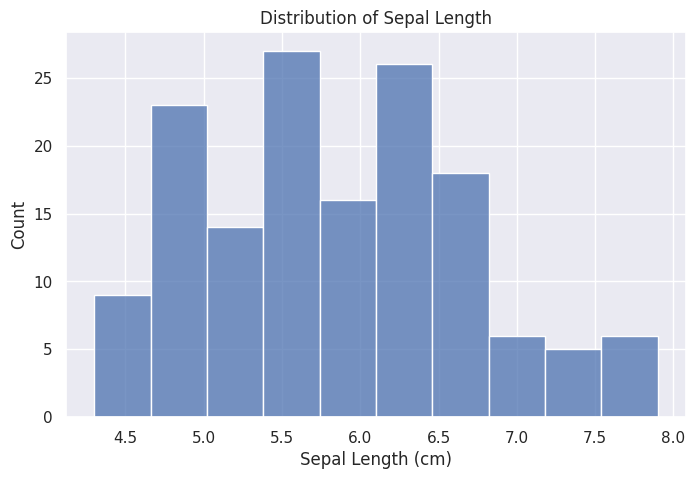

In [ ]:
# Distribution of Sepal Length

plt.figure(figsize=(8,5))
plt.hist(df['sepal length (cm)'], bins=10)
plt.title('Distribution of Sepal Length')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Count')
plt.show()

The histogram shows the distribution of sepal length values. Most observations are concentrated in the middle range, with fewer flowers at the lower and higher values.


### Distribution of Petal Length

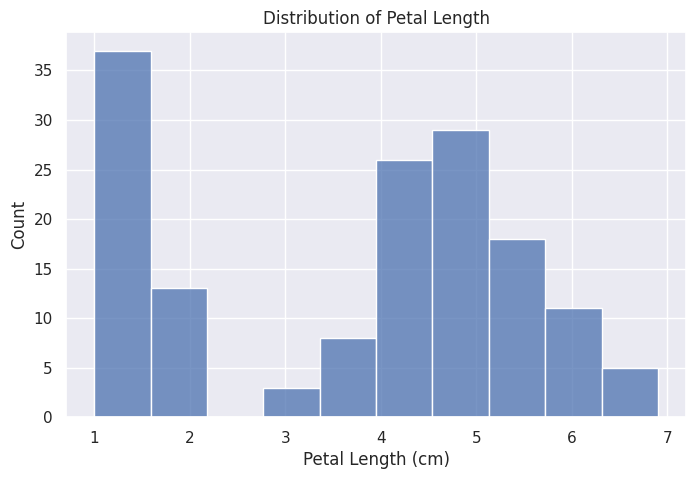

In [ ]:
# Distribution of Petal Length

plt.figure(figsize=(8,5))
plt.hist(df['petal length (cm)'], bins=10)
plt.title('Distribution of Petal Length')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Count')
plt.show()

The histogram shows the distribution of petal length values. The values form distinct ranges, reflecting differences among the Iris species.


## Bivariate Analysis

### Number of Flowers by Species

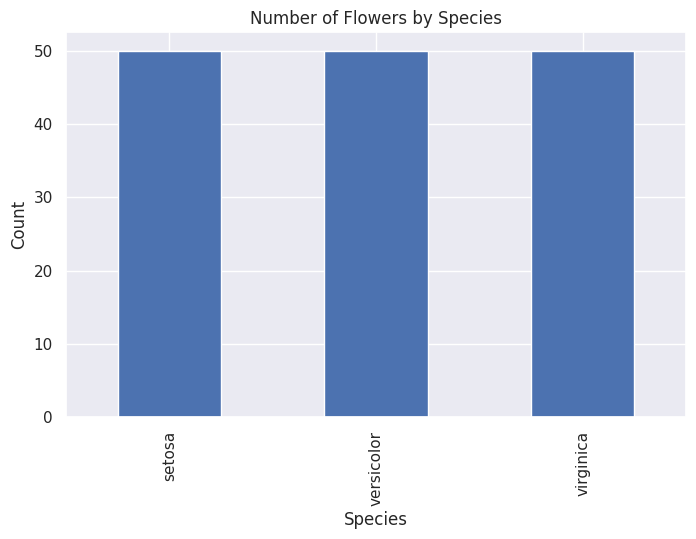

,count
species,
setosa,50
versicolor,50
virginica,50


In [ ]:
# Number of Flowers by Species

species_count = df['species'].value_counts()

plt.figure(figsize=(8,5))
species_count.plot(kind='bar')
plt.title('Number of Flowers by Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

species_count

The bar chart shows the number of flowers in each Iris species. Each species has 50 observations, so the dataset is balanced across the three species.


### Average Petal Length by Species

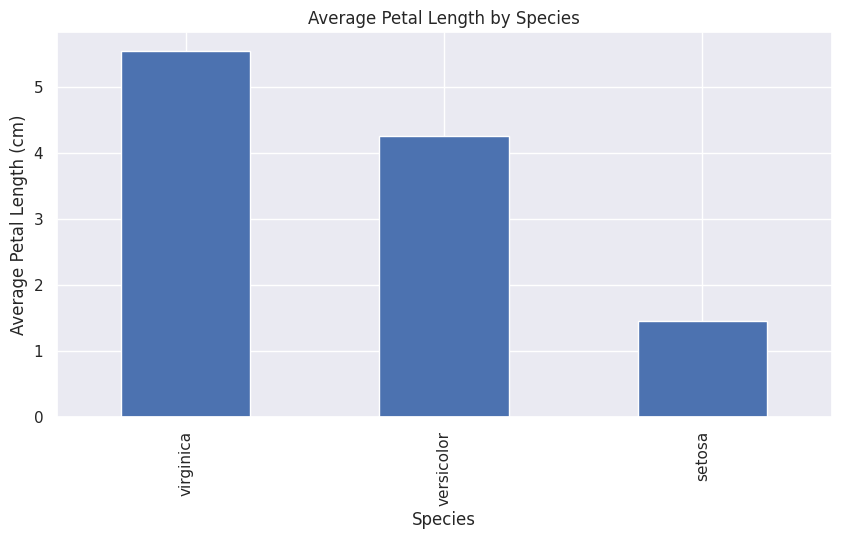

,petal length (cm)
species,
virginica,5.552
versicolor,4.260
setosa,1.462


In [ ]:
# Average Petal Length by Species

species_petal_length = df.groupby('species')['petal length (cm)'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
species_petal_length.plot(kind='bar')
plt.title('Average Petal Length by Species')
plt.xlabel('Species')
plt.ylabel('Average Petal Length (cm)')
plt.show()

species_petal_length

The average petal length differs clearly between species. Setosa has the smallest average petal length, while virginica has the largest average petal length.


### Average Sepal Width by Species

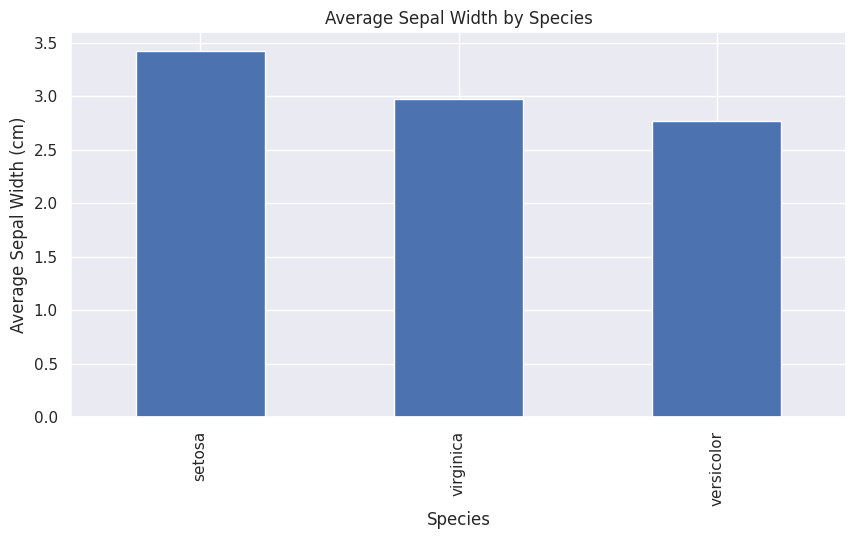

,sepal width (cm)
species,
setosa,3.428
virginica,2.974
versicolor,2.770


In [ ]:
# Average Sepal Width by Species

species_sepal_width = df.groupby('species')['sepal width (cm)'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
species_sepal_width.plot(kind='bar')
plt.title('Average Sepal Width by Species')
plt.xlabel('Species')
plt.ylabel('Average Sepal Width (cm)')
plt.show()

species_sepal_width

The average sepal width varies across species. Setosa has the highest average sepal width, while versicolor has the lowest average sepal width.


### Sepal Length vs Petal Length Relationship

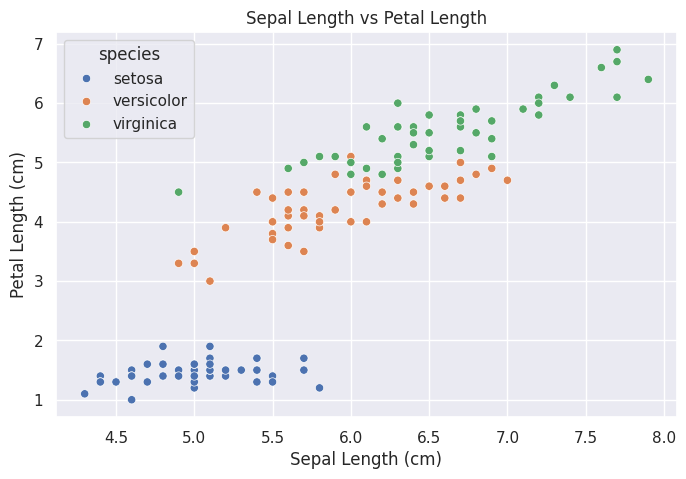

In [ ]:
# Sepal Length vs Petal Length Relationship

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='sepal length (cm)',
    y='petal length (cm)',
    hue='species',
    data=df
)

plt.title('Sepal Length vs Petal Length')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.show()

The scatter plot shows a positive relationship between sepal length and petal length. The species form noticeably different groups, especially setosa compared with versicolor and virginica.


### Correlation Matrix

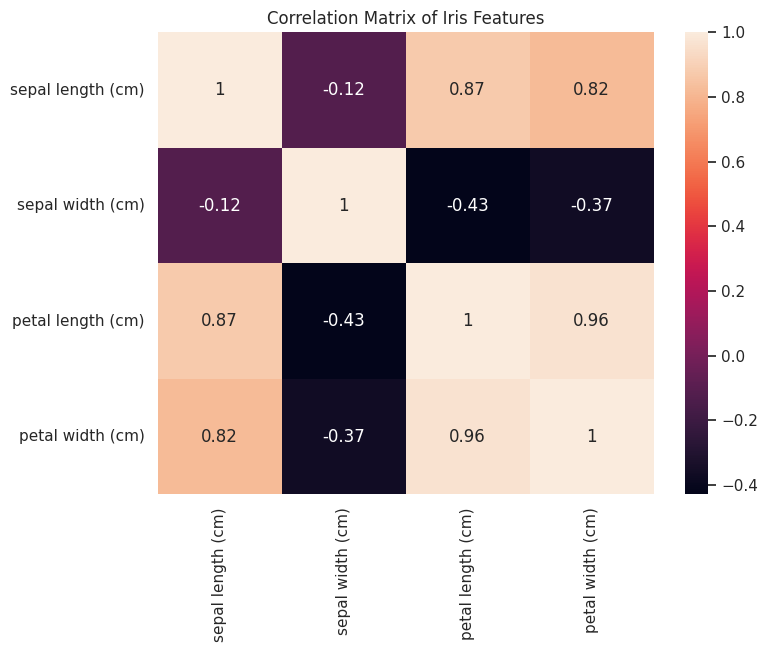

In [ ]:
# Correlation Matrix for Iris Features

plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop(columns=['species']).corr(),
    annot=True
)

plt.title('Correlation Matrix of Iris Features')
plt.show()

The correlation matrix shows the strength of the relationships among the four numerical Iris features. Petal length and petal width have a strong positive correlation, while sepal width has weaker relationships with the other features.


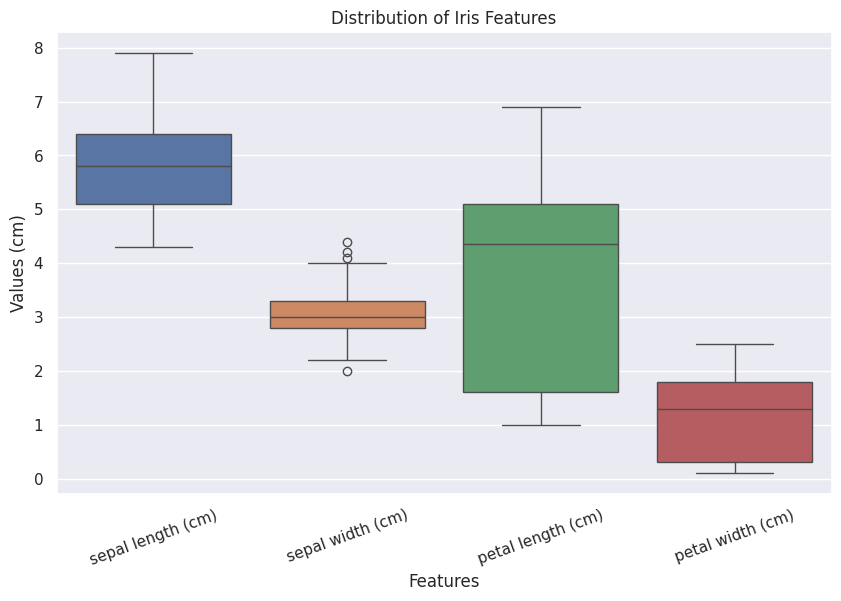

In [ ]:
# Distribution of Iris Features

plt.figure(figsize=(10,6))

sns.boxplot(data=df.drop(columns=['species']))

plt.title('Distribution of Iris Features')
plt.xlabel('Features')
plt.ylabel('Values (cm)')
plt.xticks(rotation=20)
plt.show()

The boxplot shows the distribution of the four numerical features in the Iris dataset. Petal length and petal width show greater variation, while sepal width has a smaller spread. The boxplot also helps identify possible outliers in the dataset.


# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the dataset file with your notebook.


End of lab 3.